In [4]:
!pip install kaggle -q

In [5]:
import os
import json

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [6]:
kaggle_config=json.load(open("kaggle.json"))

In [7]:
kaggle_config.keys()

dict_keys(['username', 'key'])

In [8]:
os.environ['KAGGLE_USERNAME']=kaggle_config['username']
os.environ['KAGGLE_KEY']=kaggle_config['key']

In [9]:
!kaggle datasets download notshrirang/spotify-million-song-dataset

Dataset URL: https://www.kaggle.com/datasets/notshrirang/spotify-million-song-dataset
License(s): CC0-1.0
100% 20.7M/20.7M [00:00<00:00, 97.6MB/s]



In [10]:
!ls

drive  kaggle.json  sample_data  spotify-million-song-dataset.zip


In [11]:
with zipfile.ZipFile('spotify-million-song-dataset.zip','r') as zip_ref:
  zip_ref.extractall()

In [12]:
df=pd.read_csv("/content/spotify_millsongdata.csv")

In [13]:
df.shape

(57650, 4)

In [14]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [16]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [17]:
top_artists=df['artist'].value_counts().head(10)
print("\nTop 10 Artists")
print(top_artists)


Top 10 Artists
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


In [18]:
df = df.sample(10000)
if 'link' in df.columns:
    df = df.drop('link', axis=1).reset_index(drop=True)

In [19]:
all_lyrics=" ".join(df['text'].dropna())
wordcloud=WordCloud(width=800,height=500,background_color='white').generate(all_lyrics)

In [20]:
df.shape

(10000, 3)

In [21]:
df.head()

,artist,song,text
0,Europe,Love Chaser,Someone's at your door tonight \r\nSomeone wa...
1,Hooverphonic,Electro Shock Faders,Long black dress \r\nHawaiian shirt \r\nKick...
2,Whitesnake,Blindman,"I was dreaming of the past, \r\nWhy do good t..."
3,Marilyn Manson,The Speed Of Pain,They slit our throats \r\nLike we were flower...
4,Chaka Khan,Coltrane Dreams,Coltrane (repeat) \r\nRound and round we'll c...


<function matplotlib.pyplot.show(close=None, block=None)>

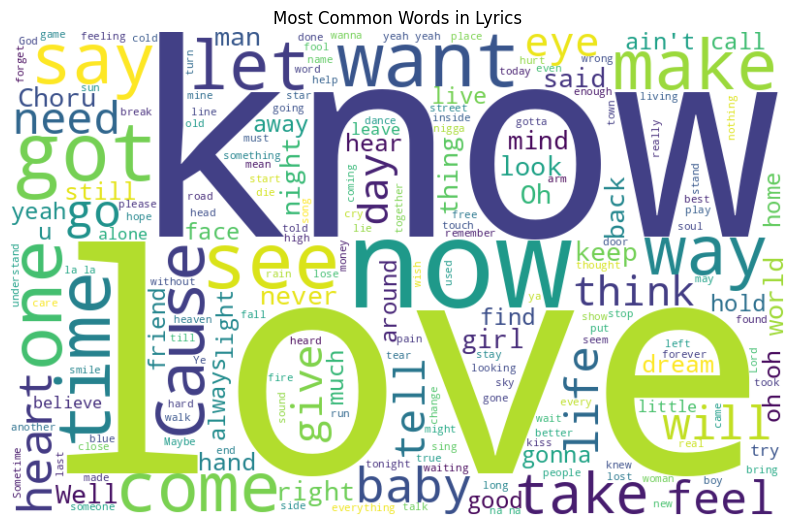

In [22]:
plt.figure(figsize=(10,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Lyrics")
plt.show

In [23]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
stop_words=set(nltk.corpus.stopwords.words('english'))

In [25]:
def preprocess_text(text):
  #removing special characters and numbers
  text=re.sub(r"[^a-zA-Z\s]","",text)
  #convertinhg to lower case
  text=text.lower()
  #tokenize and remove stopwords
  tokens=word_tokenize(text)
  tokens=[word for word in tokens if word not in stop_words]
  return " ".join(tokens)

In [26]:
#applying preprocessing to lyrics
df['cleaned_text']=df['text'].apply(preprocess_text)

In [27]:
#vectorization with TF-IDF
tfidf_vectorizer=TfidfVectorizer(max_features=5000)
tfidf_matrix=tfidf_vectorizer.fit_transform(df['cleaned_text'])


In [28]:
# taking out cosine similarity
cosine_sim=cosine_similarity(tfidf_matrix,tfidf_matrix)

In [29]:
#recommendation function
def recommend_songs(song_name,cosine_sim=cosine_sim,df=df,top_n=5):
  #finding the index of the song
  idx=df[df['song'].str.lower()==song_name.lower()].index
  if len(idx)==0:
    return "SOng not found in the dataset!!" #can be reworked to compare for songs not present in the dataset
  idx=idx[0]

  #get the similartiy scores of the songs
  sim_scores=list(enumerate(cosine_sim[idx]))
  sim_scores=sorted(sim_scores,key=lambda x:x[1],reverse=True)
  sim_scores=sim_scores[1:top_n+1]

  #get song indices
  song_indices=[i[0] for i in sim_scores]

  #return top n similar songs
  return df[['artist','song']].iloc[song_indices]

In [30]:
df["song"][2]

'Blindman'

In [33]:
#example recommendation
print("\nRecommendations for the song 'Blinded By Rainbows':")
recommendations=recommend_songs("Blindman") #df["song"][2]
print(recommendations)


Recommendations for the song 'Blinded By Rainbows':
                  artist                              song
9971               Adele                     Need You Know
2178       Rascal Flatts                        Lean On Me
6487        Donna Summer                    Now I Need You
6571  Olivia Newton-John                           The Key
9688      Rolling Stones  Everybody Needs Somebody To Love
